In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

In [5]:
from mlxtend.plotting import plot_decision_regions

In [7]:
!curl https://s3.amazonaws.com/weclouddata/datasets/random/darts/train.csv


ID,XCoord,YCoord,Competitor
111,0.943353753053659,-0.184819280466839,Bob
92,0.121557270298179,-0.927655733596588,Bob
20,0.818484897644075,0.375436699190861,Bob
75,0.867461882752652,-0.159851215141986,Sue
10,-0.817320604866736,-0.373419106492314,Kate
7,-0.236731319599013,0.470827283984837,Mark
42,0.573532895276678,-0.207807405239421,Bob
177,0.757089055219207,0.254410859973816,Sue
9,0.228493164528484,-0.573026550581115,Kate
24,-0.0163027089304782,0.227632648033017,Kate
165,-0.75153557725895,0.362479344949352,Sue
16,-0.0931395836808329,0.587120374704027,Mark
180,-0.184078161028358,-0.157282162494871,Mark
118,-0.847113276603723,0.409420812218176,Mark
1,0.703672418330267,0.0520881912386302,Sue
147,0.0925343133235891,-0.162098533568888,Mark
89,0.367314415029624,0.624808470059377,Sue
72,-0.305287223785125,-0.596659250989579,Kate
146,-0.4311949883692,-0.861792365735559,Bob
100,-0.178243071908988,-0.810978898487675,Sue
11,0.184915617592487,0.117879353127993,Mark
23,0.171887299135008,0.097748717

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100  6774  100  6774    0     0   4709      0  0:00:01  0:00:01 --:--:--  4720


In [8]:
!curl https://s3.amazonaws.com/weclouddata/datasets/random/darts/test.csv

ID,XCoord,YCoord,Competitor
6,0.0647286707976468,0.356982866833863,Mark
12,-0.766731410146258,-0.255875727260541,Sue
22,0.182281999023153,-0.54097605004082,Mark
34,-0.908910204932327,0.223945198789769,Bob
47,0.99222975688704,-0.0855495738865813,Bob
50,-0.648916140871275,-0.347688253974028,Sue
54,0.514885557503702,-0.829834629732119,Bob
56,-0.229440021070796,-0.821659468005142,Sue
60,-0.257081089328837,-0.595977351112783,Mark
61,-0.65623000206627,-0.691064377885939,Bob
62,-0.124922399956618,0.0404688273341698,Mark
63,0.132841895895659,-0.377382213335957,Mark
67,-0.139376630506108,0.1214281696754,Mark
69,-0.336673815320046,0.479477856969259,Kate
71,0.765578012492546,0.417377034079962,Sue
73,-0.230442969257977,-0.280220180700956,Kate
74,-0.0821537139609364,0.172597462776142,Mark
76,0.19387893519101,0.340761715250838,Mark
88,0.262575718310364,-0.290876918292994,Kate
90,-0.504978182145579,-0.84921595043788,Bob
103,0.216201174673911,-0.170681043583832,Mark
106,-0.80105686695122,0.11419619813

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1690  100  1690    0     0   2677      0 --:--:-- --:--:-- --:--:--  2686
100  1690  100  1690    0     0   2674      0 --:--:-- --:--:-- --:--:--  2682


In [9]:
train_df = pd.read_csv('https://s3.amazonaws.com/weclouddata/datasets/random/darts/train.csv')
test_df = pd.read_csv('https://s3.amazonaws.com/weclouddata/datasets/random/darts/test.csv')

In [10]:
train_df.head()

,ID,XCoord,YCoord,Competitor
0,111,0.943354,-0.184819,Bob
1,92,0.121557,-0.927656,Bob
2,20,0.818485,0.375437,Bob
3,75,0.867462,-0.159851,Sue
4,10,-0.817321,-0.373419,Kate


In [11]:
test_df.head()

,ID,XCoord,YCoord,Competitor
0,6,0.064729,0.356983,Mark
1,12,-0.766731,-0.255876,Sue
2,22,0.182282,-0.540976,Mark
3,34,-0.908910,0.223945,Bob
4,47,0.992230,-0.085550,Bob


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()
train_df['Competitor'] = encoder.fit_transform(train_df['Competitor'])

In [14]:
test_df['Competitor'] = encoder.fit_transform(test_df['Competitor'])

In [15]:
train_df['Competitor'].value_counts()

Competitor
3    41
1    41
2    35
0    33
Name: count, dtype: int64

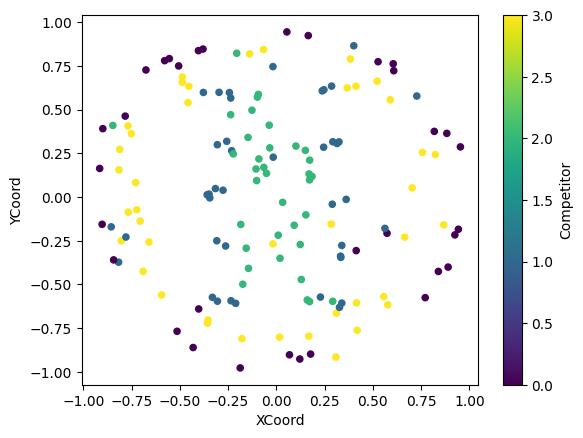

In [25]:
train_df.plot.scatter(x = 'XCoord', y = 'YCoord', c='Competitor', colormap = 'viridis' )
plt.show()



In [30]:
y_train = train_df['Competitor']
X_train = train_df[['XCoord','YCoord']]

y_test = test_df['Competitor']
X_test = test_df[['XCoord' , 'YCoord']]

In [32]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


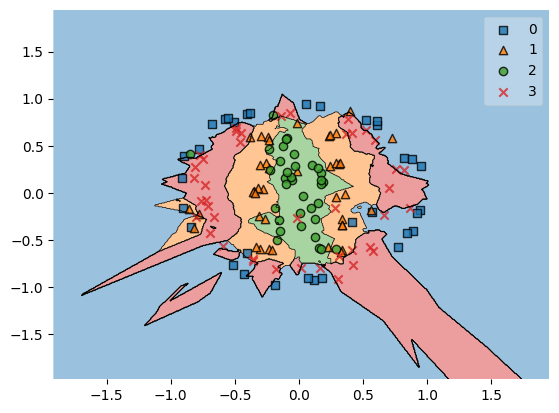

In [34]:
plot_decision_regions(X_train.values, y_train.values, clf=knn)
plt.show()

c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


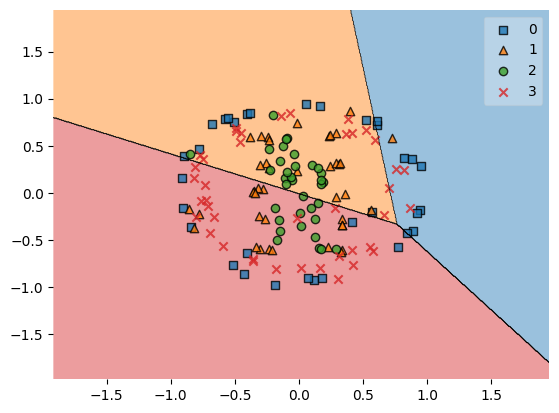

In [39]:
lr = LogisticRegression(n_jobs = -1)
lr.fit(X_train, y_train)
plot_decision_regions(X_train.values, y_train.values, clf = lr)
plt.show()


c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


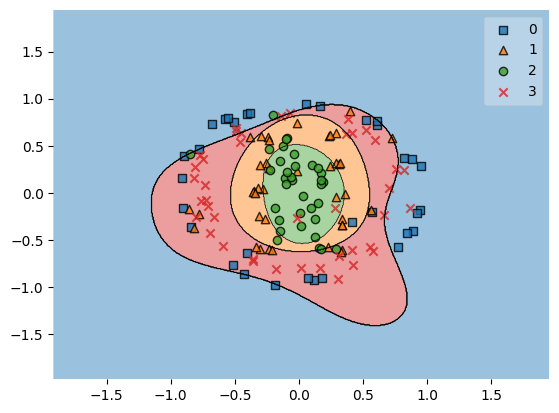

In [38]:
support_vector = SVC()
support_vector.fit(X_train, y_train)
plot_decision_regions(X_train.values, y_train.values, clf = support_vector)
plt.show()

In [ ]:
estimators = [
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier() ),
   # ('svm', SVC())
]

c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

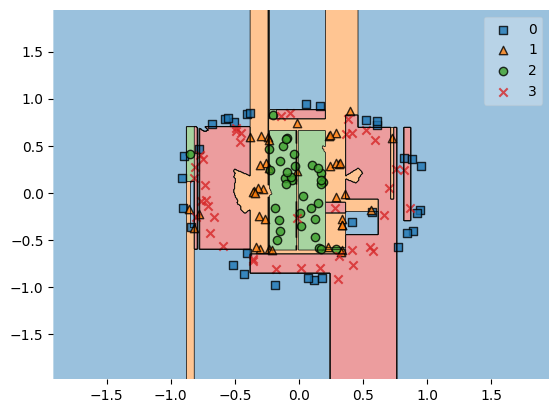

In [46]:
vclf = VotingClassifier(estimators=estimators, n_jobs=-1, voting='soft')

vclf.fit(X_train, y_train)
plot_decision_regions(X_train.values, y_train.values, clf=vclf)

In [49]:
estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth = 4) ),
    ('svm', SVC(C = 10)),
    ('knn2', KNeighborsClassifier(n_neighbors=7)),
    ('dt2', DecisionTreeClassifier(max_depth = 6) ),
    ('svm2', SVC(C = 30)) 
]

c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.p

<Axes: >

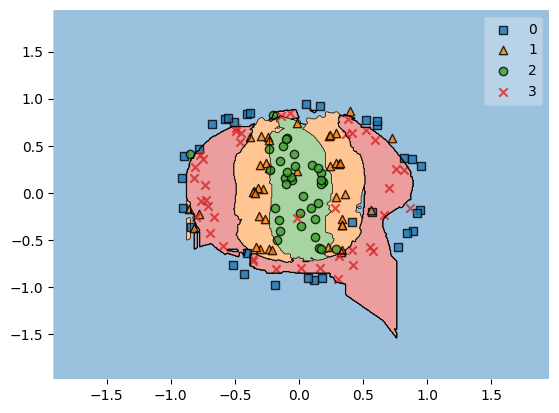

In [50]:
vclf = VotingClassifier(estimators=estimators, voting='hard')

vclf.fit(X_train, y_train)
plot_decision_regions(X_train.values, y_train.values, clf=vclf)

c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

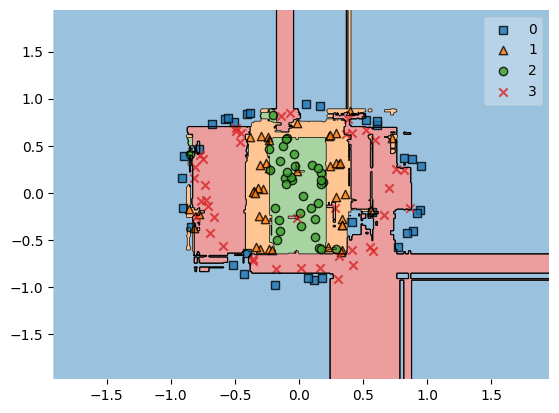

In [51]:
from sklearn.ensemble import RandomForestClassifier

rand_forest = RandomForestClassifier(n_estimators=50)
rand_forest.fit(X_train, y_train)

plot_decision_regions(X_train.values, y_train.values, clf=rand_forest)

In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier()


c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


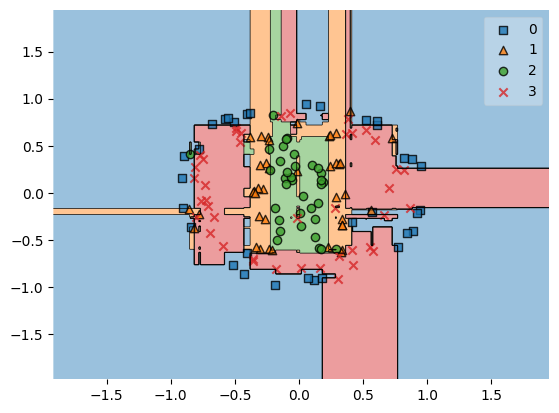

In [54]:
xgb.fit(X_train, y_train )

plot_decision_regions(X_train.values, y_train.values, clf=xgb)

plt.show()